# Tutorial 06: Exploratory Data Analysis

Author: Georg Ahnert

In this notebook we will use TF-IDF for an exploratory comparison of texts. We will also look into how to create some common visualizations with seaborn.

In [ ]:
# Install dependencies
!pip install scikit-learn nltk seaborn

## Comparing Texts with TF-IDF

In the first part of this notebook, we will explore documents based on (normalized) word counts. We will closely follow the sklearn pipeline that you can also find here: https://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction

In [3]:
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import Pipeline

First, let's count the occurences of words from a specific vocubulary in this example corpus of three documents:

In [4]:
corpus = ['this is the first document',
          'this document is the second document',
          'and this is the third one']

vocabulary = ['this', 'document', 'first', 'second', 'third']

In [5]:
vectorizer = CountVectorizer(vocabulary=vocabulary) # initialize counting on a specific vocabulary
X = vectorizer.fit_transform(corpus)
X.toarray() # we get a sparse matrix of shape (n_documents x n_words)

array([[1, 1, 1, 0, 0],
       [1, 2, 0, 1, 0],
       [1, 0, 0, 0, 1]])

Some of these words are not very informative since they occur in mutiple/all documents (e.g., "this"). We can use TF-IDF to account for this issue.

In it's default settings, the `TfidfTransformer` calculates the inverse document frequence $\text{idf}$ of a term $t$ as

$\text{idf}(t) = \log{\frac{1 + n}{1+\text{df}(t)}} + 1$

In [6]:
transf = TfidfTransformer()
X2 = transf.fit_transform(X)
X2.toarray() # due to our limited vocubulary, "third" becomes the most important word overall

array([[0.42544054, 0.54783215, 0.72033345, 0.        , 0.        ],
       [0.30861775, 0.7948031 , 0.        , 0.52253528, 0.        ],
       [0.50854232, 0.        , 0.        , 0.        , 0.861037  ]])

We can wrap everything into a `Pipeline` to make it a bit more convenient and use the `ngram_range` parameter to automatically build a vocabulary of 1-3 words:

In [7]:
pipe = Pipeline(
    [
        ('count', CountVectorizer(ngram_range=(1,3))),
        ('tfidf', TfidfTransformer())
    ]
)
X = pipe.fit_transform(corpus)
X.toarray()

array([[0.        , 0.        , 0.        , 0.2667197 , 0.        ,
        0.        , 0.35070436, 0.35070436, 0.20713164, 0.20713164,
        0.35070436, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.20713164, 0.35070436, 0.35070436, 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.20713164, 0.        , 0.        , 0.2667197 , 0.2667197 ],
       [0.        , 0.        , 0.        , 0.42666776, 0.28050841,
        0.28050841, 0.        , 0.        , 0.16567279, 0.16567279,
        0.        , 0.28050841, 0.        , 0.        , 0.28050841,
        0.28050841, 0.16567279, 0.        , 0.        , 0.28050841,
        0.28050841, 0.        , 0.        , 0.        , 0.        ,
        0.16567279, 0.28050841, 0.28050841, 0.        , 0.        ],
       [0.29421809, 0.29421809, 0.29421809, 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.17376994, 0.17376994,
        0.        , 0.        , 0.29421809, 0.

In [8]:
pipe['count'].vocabulary_

{'this': 25,
 'is': 8,
 'the': 16,
 'first': 6,
 'document': 3,
 'this is': 28,
 'is the': 9,
 'the first': 17,
 'first document': 7,
 'this is the': 29,
 'is the first': 10,
 'the first document': 18,
 'second': 14,
 'this document': 26,
 'document is': 4,
 'the second': 19,
 'second document': 15,
 'this document is': 27,
 'document is the': 5,
 'is the second': 11,
 'the second document': 20,
 'and': 0,
 'third': 23,
 'one': 13,
 'and this': 1,
 'the third': 21,
 'third one': 24,
 'and this is': 2,
 'is the third': 12,
 'the third one': 22}

## Applying TF-IDF to samples of tweets

Let's try this out on a bigger scale using tweets that are included in `nltk.corpus`. We'll create two documents based on the sets of tweets included there and process them with our pipeline. 

Note that since we only have two documents, we still want to exclude stopwords like "and", etc. from counting, since TF-IDF might not be aggressive enough in filtering them out.

In [ ]:
import nltk
nltk.download('twitter_samples') # download NLTK Twitter data

In [9]:
from nltk.corpus import twitter_samples

twitter_samples.strings('positive_tweets.json')[:5]

['#FollowFriday @France_Inte @PKuchly57 @Milipol_Paris for being top engaged members in my community this week :)',
 '@Lamb2ja Hey James! How odd :/ Please call our Contact Centre on 02392441234 and we will be able to assist you :) Many thanks!',
 '@DespiteOfficial we had a listen last night :) As You Bleed is an amazing track. When are you in Scotland?!',
 '@97sides CONGRATS :)',
 'yeaaaah yippppy!!!  my accnt verified rqst has succeed got a blue tick mark on my fb profile :) in 15 days']

In [10]:
twitter_samples.strings('negative_tweets.json')[:5]

['hopeless for tmr :(',
 "Everything in the kids section of IKEA is so cute. Shame I'm nearly 19 in 2 months :(",
 '@Hegelbon That heart sliding into the waste basket. :(',
 '“@ketchBurning: I hate Japanese call him "bani" :( :(”\n\nMe too',
 'Dang starting next week I have "work" :(']

In [40]:
from sklearn.feature_extraction import text
# Create a custom list by adding to the defaults
my_additional_stop_words = ['https', 'http', 'rt', 'co', 'amp']
final_stop_words = list(text.ENGLISH_STOP_WORDS.union(my_additional_stop_words))

corpus = [
    ' '.join(twitter_samples.strings('positive_tweets.json')), # put all positive tweets together into one document
    ' '.join(twitter_samples.strings('negative_tweets.json')), # same for negative tweets
]

pipe = Pipeline(
    [
        ('count', CountVectorizer(stop_words=final_stop_words)),
        ('tfidf', TfidfTransformer())
    ]
)
X = pipe.fit_transform(corpus)

In [41]:
X.toarray()[0]

array([0.00177932, 0.01125349, 0.        , ..., 0.        , 0.        ,
       0.        ])

In [44]:
feature_names = pipe.named_steps['count'].get_feature_names_out()
scores_pos = X.toarray()[0]
scores_neg = X.toarray()[1]

matched_pos = sorted(zip(scores_pos, feature_names), reverse=True)
matched_pos[:10]

[(0.34963699458425557, 'thanks'),
 (0.2740157616589077, 'follow'),
 (0.24465693005259614, 'love'),
 (0.22063606782925033, 'thank'),
 (0.20907046749949124, 'good'),
 (0.1948358824782493, 'like'),
 (0.18860825153145594, 'day'),
 (0.1752633280740416, 'just'),
 (0.1752633280740416, 'happy'),
 (0.15391145054217867, 'hi')]

In [45]:
matched_neg = sorted(zip(scores_neg, feature_names), reverse=True)
matched_neg[:10]

[(0.2584237749297415, 'miss'),
 (0.2573425039049309, 'just'),
 (0.2357170834087182, 'want'),
 (0.2227418311109906, 'like'),
 (0.197872597540346, 'don'),
 (0.16110938269678446, 'sorry'),
 (0.15354048552311003, 'follow'),
 (0.15245921449829938, 'time'),
 (0.1438090462998143, 'really'),
 (0.1438090462998143, 'love')]

Further processing might be required to improve how texts are split into words, how similar words in different forms are handled ("run" vs. "ran", "bird" vs. "birds", etc.), and much more. See also: https://scikit-learn.org/stable/modules/feature_extraction.html#tips-and-tricks

## Exploring Data with Visualizations

[Seaborn](https://seaborn.pydata.org/) is particularly well-suited for exploratory data analysis, because it allows you to create plots quickly without specifying too many parameters/calling lots of functions to get to your plot.

We will re-use the Quality of Government Dataset from exercise 1.

In [47]:
import pandas as pd
import seaborn as sns

### Types of Plots

1/2/3 Variables?

Categorical/Continuous Data?

![seaborn](https://seaborn.pydata.org/_images/function_overview_8_0.png)

Image credit: https://seaborn.pydata.org/tutorial/function_overview.html

In [68]:
# load the QoG dataset
df = pd.read_csv("http://www.qogdata.pol.gu.se/data/qog_std_cs_jan22.csv")

df = df[["cname", "wdi_pop", "wdi_popgr", "wdi_gdpcapcur", "wdi_gdpcapgr", "wdi_area", "wdi_broadb", "ht_region"]]
df = df.rename(columns={"cname" : "name",
            "wdi_pop" : "population",
            "wdi_popgr" : "population_growth",
            "wdi_gdpcapcur" : "gdp_per_capita",
            "wdi_gdpcapgr" : "gdp_growth",
            "wdi_area" : "area",
            "wdi_broadb" : "internet",
            "ht_region" : "region"
           })

regions = {
    1: "Eastern Europe",
    2: "Latin America",
    3: "North Africa & Middle East",
    4: "Sub-Saharan Africa",
    5: "W. Europe & N. America",
    6: "East Asia",
    7: "South-East Asia",
    8: "South Asia",
    9: "Pacific",
    10: "Caribbean",
}

df['region'] = df['region'].replace(regions).astype('category')
df.head()

,name,population,population_growth,gdp_per_capita,gdp_growth,area,internet,region
0,Afghanistan,37171920.0,2.384309,493.756592,-1.194900,652860.0,0.043041,South Asia
1,Albania,2866376.0,-0.246732,5284.380371,4.328395,27400.0,12.555659,Eastern Europe
2,Algeria,42228416.0,2.007399,4153.956055,-0.811233,2381741.0,7.262936,North Africa & Middle East
3,Andorra,77008.0,0.014285,41791.968750,1.574254,470.0,46.311977,W. Europe & N. America
4,Angola,30809788.0,3.276145,3289.644043,-5.162112,1246700.0,0.355605,Sub-Saharan Africa


## Relational Data
### Does a growing population coincide with a growing GDP?

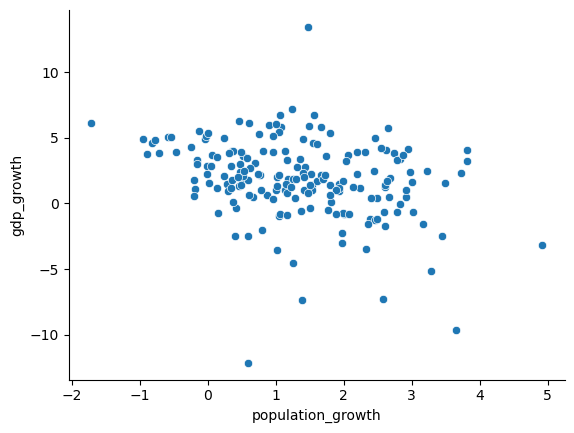

In [69]:
sns.scatterplot(df, x='population_growth', y='gdp_growth')
sns.despine() # remove top and right spine to increase the data-ink ratio

### Does this also hold within regions?

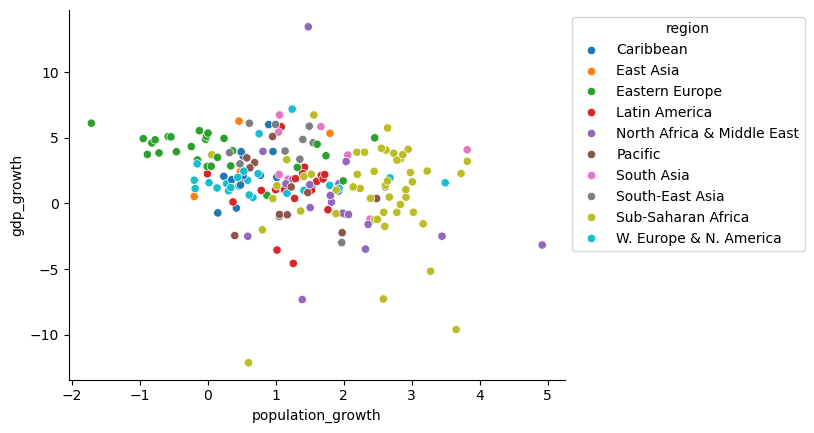

In [79]:
ax = sns.scatterplot(df, x='population_growth', y='gdp_growth', hue='region')
sns.despine()
sns.move_legend(ax, loc='upper left', bbox_to_anchor=(1,1))

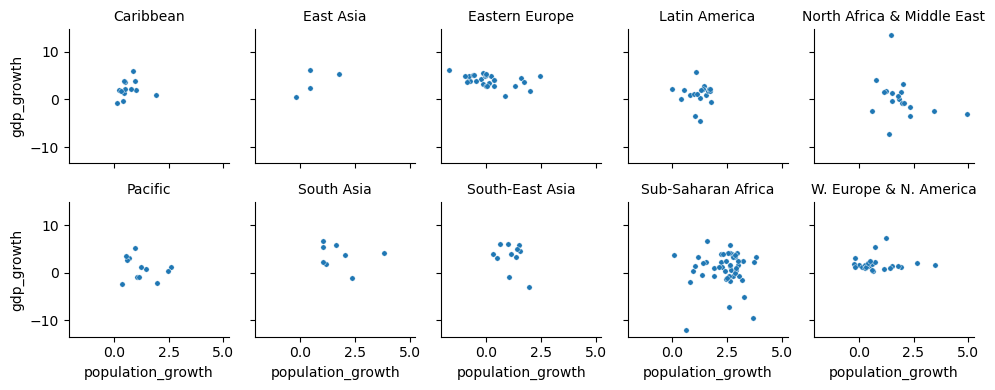

In [116]:
g = sns.relplot(
    df,
    x='population_growth',
    y='gdp_growth',
    col='region',
    col_wrap=5,
    height=2,
    s=15 # size of the scatter points to be passed to matplotlib.pyplot
)

g.set_titles("{col_name}") # shorten the subplot titles
sns.despine()

And, of course, we can also calculate correlations with pandas:

In [136]:
df.groupby('region')[['gdp_growth', 'population_growth']].corr().unstack().iloc[:,1]

region
Caribbean                     0.168696
East Asia                     0.647760
Eastern Europe               -0.428273
Latin America                 0.012362
North Africa & Middle East   -0.297143
Pacific                      -0.236906
South Asia                   -0.212506
South-East Asia              -0.348518
Sub-Saharan Africa            0.026972
W. Europe & N. America        0.021750
Name: (gdp_growth, population_growth), dtype: float64

## Distributions
### How is population size distributed across countries?

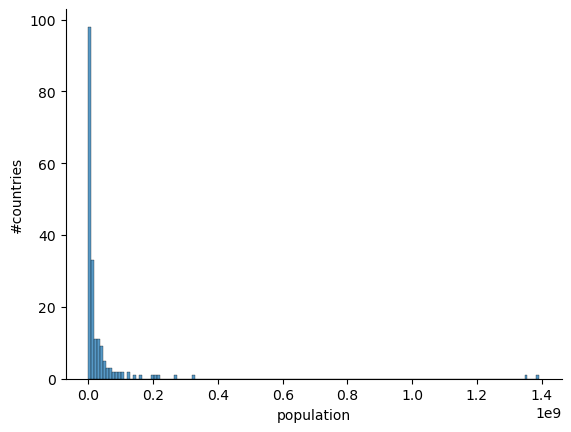

In [ ]:
ax = sns.histplot(df, x='population') # maybe not super informative due to a few very large countries
ax.set_ylabel("#countries") # adjust the automatically generated y-label to something meaningful
sns.despine()

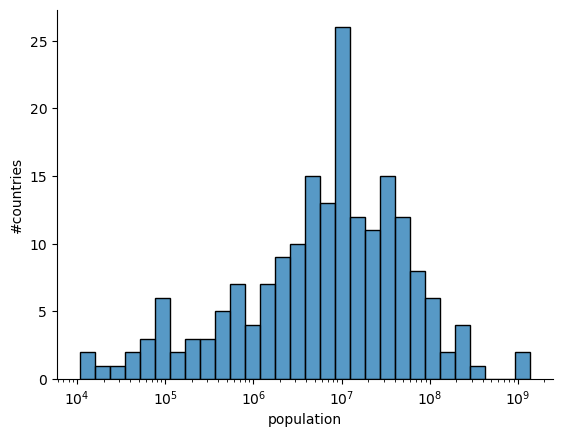

In [157]:
ax = sns.histplot(df, x='population', log_scale=True, bins=30)
ax.set_ylabel("#countries")
sns.despine()

Overlapping barcharts are generally hard to interpret, so it might be a good idea to use separate subplots

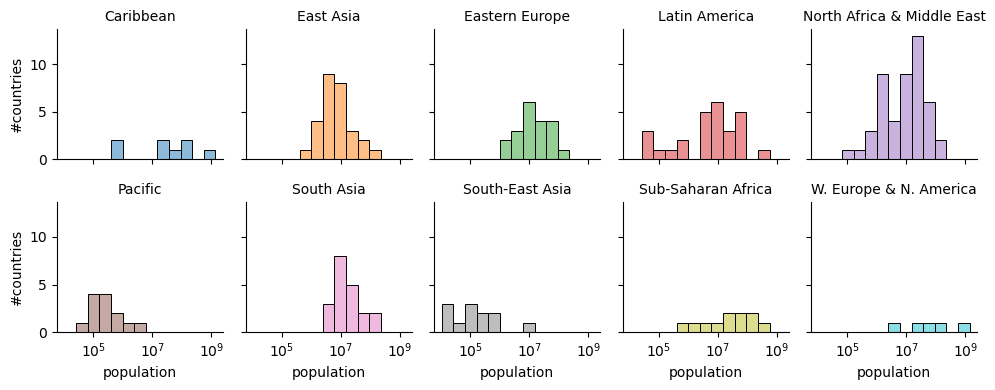

In [158]:
g = sns.displot(
    df,
    x='population',
    log_scale=True,
    col='region',
    col_wrap=5,
    hue='region',
    legend=False, # specifying hue automatically creates a legend, but we don't need it here
    height=2,
)
g.set_titles("{col_name}") # shorten the subplot titles
g.set_ylabels("#countries")
sns.despine()

### What does the joint distribution of population and GDP per capita look like?

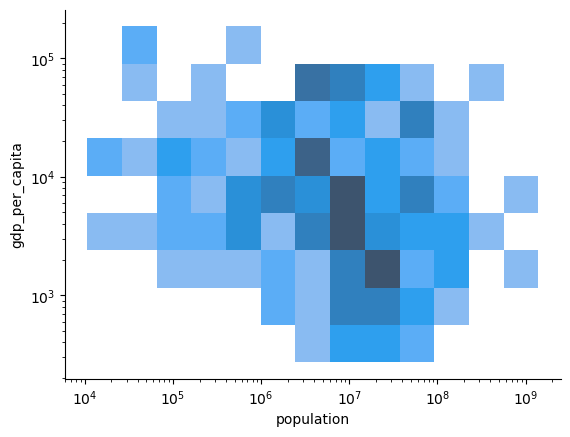

In [112]:
sns.histplot(df, x='population', y='gdp_per_capita', log_scale=True) # notice how histplots are really good at showing "overlapping" datapoints, i.e., density 
sns.despine()

## Categorical Data
### How many countries per region are in the dataset?

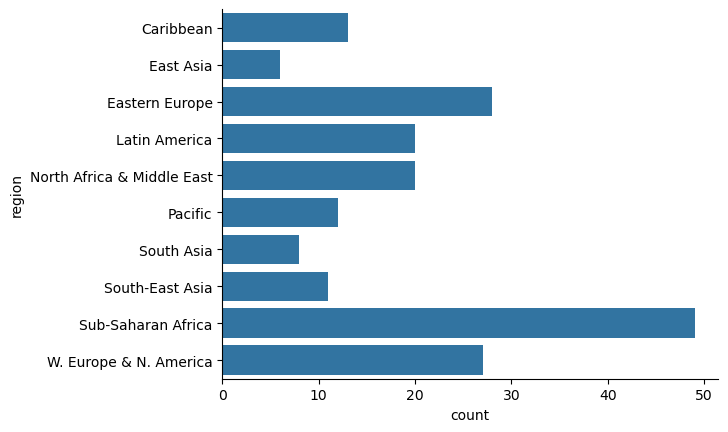

In [141]:
sns.countplot(df, y='region') # instead of rotating labels on the x-axis, use the y-axis for categorical values -> easier to read!
sns.despine()

### How is the internet availability distributed in each region?

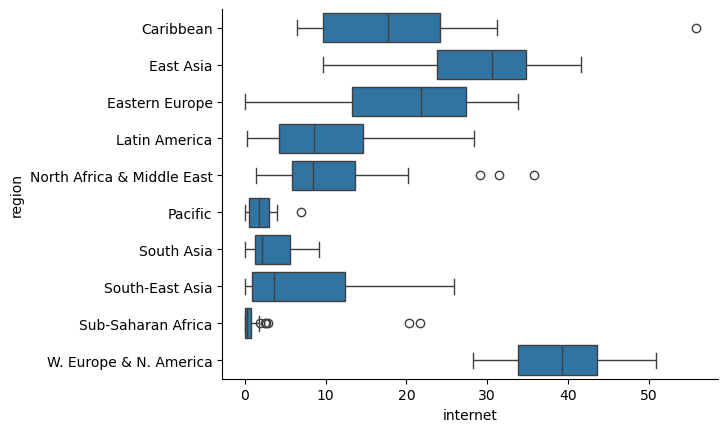

In [140]:
sns.boxplot(df, y='region', x='internet')
sns.despine()

Boxplots can get difficult to read if you have too many categories. So you could also (i) group the instances and count, or (ii) use lineplots as a simplified form of box plots.

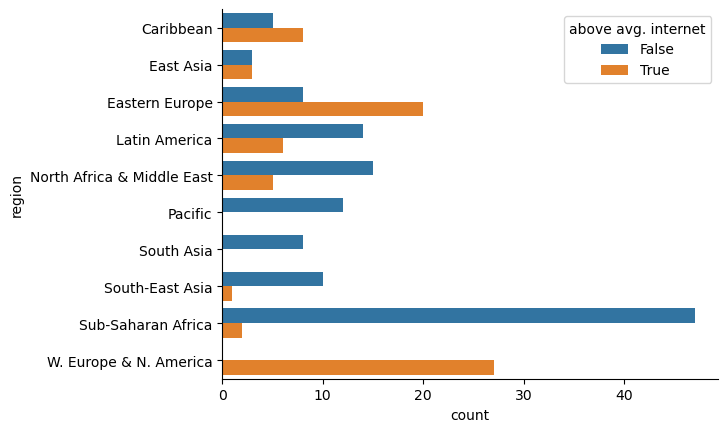

In [ ]:
df['above avg. internet'] = df.internet > df.internet.mean()

sns.countplot(df, y='region', hue='above avg. internet') # setting a hue automatically creates a paired bar chart
sns.despine()

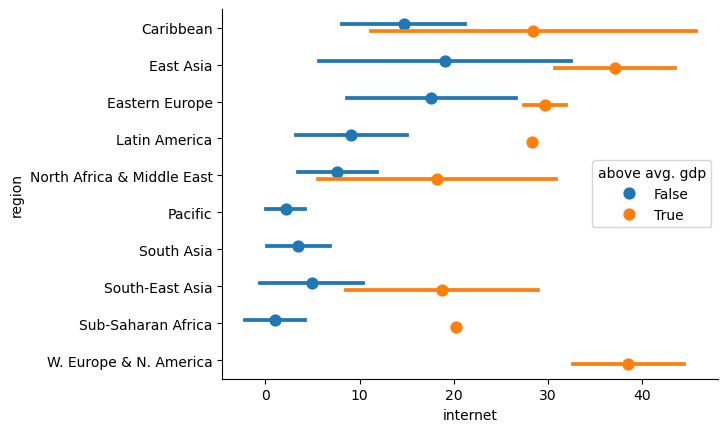

In [154]:
df['above avg. gdp'] = df.gdp_per_capita > df.gdp_per_capita.mean()

sns.pointplot(
    df,
    y='region',
    x='internet',
    hue='above avg. gdp',
    dodge=.2, # add space between paired points
    linestyle='none', # no lines between the categories
    errorbar="sd" # custom error bars (default is 95% CI)
)
sns.despine()

## Styling Seaborn Plots

Seaborn allows you to change global values for figure aesthetics, sizes, and colors somewhat easily. See also https://seaborn.pydata.org/tutorial/aesthetics.html and https://seaborn.pydata.org/tutorial/color_palettes.html

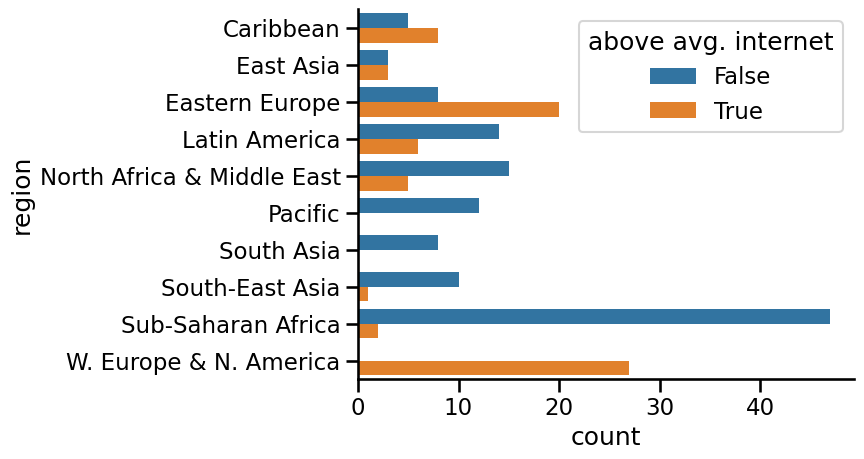

In [ ]:
sns.set_context("talk") # adjust figure size and font size for presentations (or single column figures in a double-column paper layout)

sns.countplot(df, y='region', hue='above avg. internet')
sns.despine()

In [ ]:
sns.set_context('notebook') # back to the regular size

Qualitative (categorical) color palettes can be used with a context manager:

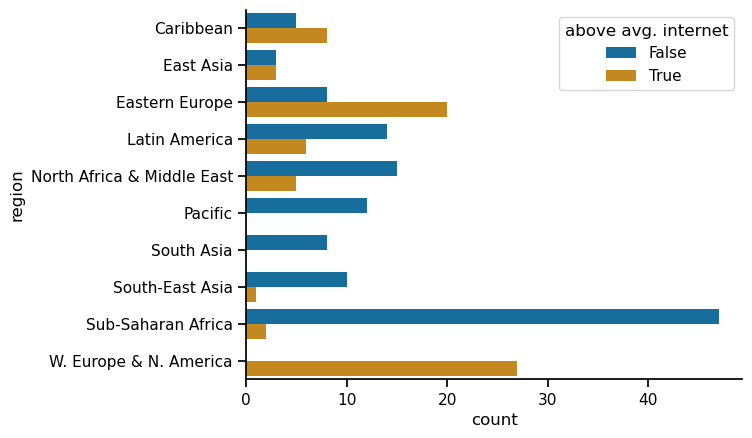

In [190]:
with sns.color_palette('colorblind'):
    sns.countplot(df, y='region', hue='above avg. internet')
    sns.despine()

You can also define custom colors using names shown [here](https://matplotlib.org/stable/users/explain/colors/colors.html) or with Hex codes, but **keep readability and accessibility in mind!**

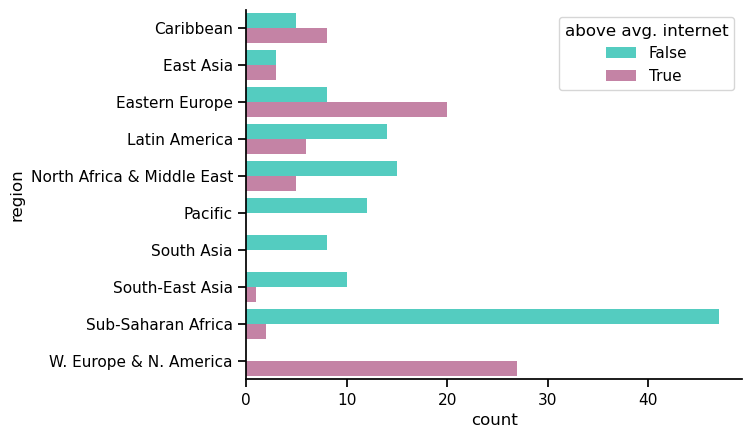

In [188]:
colors = [
    'turquoise',
    "#CF78A6"
]

with sns.color_palette(colors):
    sns.countplot(df, y='region', hue='above avg. internet')
    sns.despine()

Sequential (continuous) color palettes can be passed directly to some of the plot types:

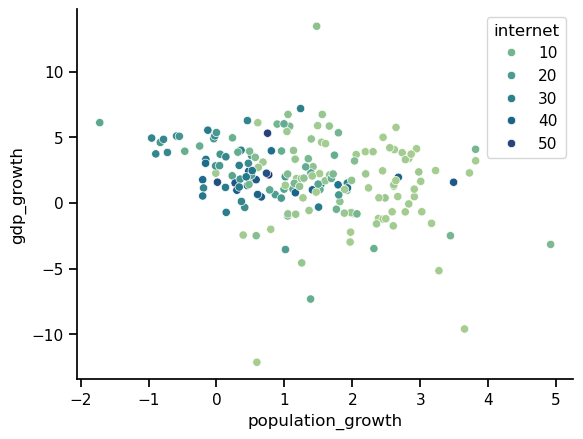

In [178]:
sns.scatterplot(
    df,
    x='population_growth',
    y='gdp_growth',
    hue='internet',
    palette=sns.color_palette("crest", as_cmap=True)
)
sns.despine()